In [1]:
import distutils.spawn
from functools import partial

import jax
from jax import numpy as jnp
from jax import random
from matplotlib import pyplot as plt
from matplotlib import rc
import pandas as pd
import seaborn as sns

In [2]:
sns.set(font_scale=2.0)
if distutils.spawn.find_executable("latex"):
    rc("font", **{"family": "serif", "serif": ["Computer Modern"]})
    rc("text", usetex=True)

/var/folders/5t/1858x_sn3kz5tw252hv5nw3w0000gn/T/ipykernel_53368/3010401971.py:2: DeprecationWarning: Use shutil.which instead of find_executable
  if distutils.spawn.find_executable("latex"):


In [3]:
# x is a d-dim vector
def layer_norm_single_token(x):
    mu = jnp.mean(x)
    sigma = jnp.std(x)
    return (x-mu)/(sigma+1e-5)

In [4]:
layer_norm = jax.vmap(layer_norm_single_token, in_axes=0)

In [5]:
# X is a Lxd matrix, W_k, W_q are rxd, W_v is dxd
def single_head_attention_layer(X, W_k, W_q, W_v):
    r = W_k.shape[0]
    normed_X = layer_norm(X)
    attention_matrix = (normed_X @ W_k.T) @ (W_q @ normed_X.T) / jnp.sqrt(r)   # LxL
    attention_matrix_after_softmax = jax.nn.softmax(attention_matrix, axis=1)
    return X + attention_matrix_after_softmax @ normed_X @ W_v   # Lxd

In [6]:
# X is a d-dim vector, W_1 is mxd, W_2 is dxm
def ff_layer_single_token(x, W_1, W_2, b_1, b_2):
    return x + W_2 @ jax.nn.relu(W_1@x + b_1) + b_2

In [7]:
ff_layer = jax.vmap(ff_layer_single_token, in_axes=[0, None, None, None, None])

In [8]:
# keep only the first coordinate of X
def linear_projector(X, theta):
    return theta @ X[0]

In [10]:
def attention_ff_proj(X, params):
    register, W_k, W_q, W_v, W_1, W_2, b_1, b_2, theta = params
    X_with_register = jnp.concatenate([register.reshape(1,-1), X], axis=0)
    after_attention = single_head_attention_layer(X_with_register, W_k, W_q, W_v)
    after_ff = ff_layer(after_attention, W_1, W_2, b_1, b_2)
    return linear_projector(after_ff, theta)

In [11]:
batched_attention_ff_proj = jax.vmap(attention_ff_proj, in_axes=[0, None], out_axes=0)

def risk_fn(X, y, params):
    """Loss with mean-squared error for our problem."""
    return jnp.mean((batched_attention_ff_proj(X, params) - y) ** 2)

grad_fn = jax.value_and_grad(risk_fn, argnums=2)

def init_star(d, key):
    """Initialization of k* and v* on the sphere."""
    subkeys = random.split(key, 2)
    k_star = random.normal(subkeys[0], shape=(d,))
    k_star = k_star / jnp.linalg.norm(k_star)
    v_star = random.normal(subkeys[1], shape=(d,))
    v_star = v_star - k_star @ v_star * k_star
    v_star = v_star / jnp.linalg.norm(v_star)
    return k_star, v_star

def generate_params(r, d, m, key):
    # Xavier initialization N(0, 2/(d_in + d_out))
    subkeys = random.split(key, 7)
    register = random.normal(subkeys[6], shape=(d,)) * jnp.sqrt(1/d)
    W_k = random.normal(subkeys[0], shape=(r,d)) * jnp.sqrt(2/(r+d))
    W_q = jnp.zeros(shape=(r,d))
    W_v = random.normal(subkeys[2], shape=(d,d)) * jnp.sqrt(1/d)
    W_1 = random.normal(subkeys[3], shape=(m,d)) * jnp.sqrt(2/(m+d))
    W_2 = random.normal(subkeys[4], shape=(d,m)) * jnp.sqrt(2/(m+d))
    b_1 = jnp.zeros(shape=(m,))
    b_2 = jnp.zeros(shape=(d,))
    theta = random.normal(subkeys[5], shape=(d,)) / d
    return register, W_k, W_q, W_v, W_1, W_2, b_1, b_2, theta

@partial(jax.jit, static_argnames=["batch_size", "d", "L"])
def generate_batch(k_star, v_star, batch_size, d, L, eps, gamma, key):
    """Generates one batch of data of the single-location regression distribution."""
    subkeys = random.split(key, 3)
    X_1 = jax.random.multivariate_normal(
        subkeys[0],
        jnp.sqrt(d / 2) * k_star,
        gamma**2 * jnp.eye(d),
        shape=(batch_size, 1),
    )
    other_X_i = jax.random.normal(subkeys[1], shape=(batch_size, L - 1, d))
    xi = eps * jax.random.normal(subkeys[2], shape=(batch_size,))
    y = X_1[:, 0, :] @ v_star + xi
    return jnp.concatenate([X_1, other_X_i], axis=1), y

@partial(jax.jit, static_argnames=["batch_size", "d", "L"])
def sgd_step(params, k_star, v_star, d, L, gamma, alpha, batch_size, eps, key):
    """One step of SGD."""
    X, y = generate_batch(k_star, v_star, batch_size, d, L, eps, gamma, key)
    risk, grad = grad_fn(X, y, params)
    register = params[0]
    params_except_register = jax.tree.map(lambda x,y: x - alpha * y, params[1:], grad[1:])
    return risk, (register,) + params_except_register, grad

In [12]:
L = 10
d = 80
r = 80
m = 200
eps = 0.1
gamma = float(jnp.sqrt(0.5))
alpha = 1e-2
batch_size = 128
test_batch_size = 1000
n_steps = 8000
log_every = 100
n_runs = 20
key = random.key(0)

logs = {
    "Run": [],
    "Step": [],
    "Excess risk": [],
    "Squared norm ratio": [],
    r"Alignment with $k^\star$": [],
    r"Alignment with $v^\star$": [],
}

run_subkeys = random.split(key, n_runs)
for run in range(n_runs):
    print("Run {}/{}".format(run+1, n_runs))
    key, subkey, subkey2, subkey3 = random.split(run_subkeys[run], 4)
    params = generate_params(r, d, m, subkey)
    k_star, v_star = init_star(d, subkey2)
    test_X, test_y = generate_batch(k_star, v_star, test_batch_size, d, L, eps, gamma, subkey3)
    logs["Run"].append(run)
    logs["Step"].append(0)
    test_risk = risk_fn(test_X, test_y, params)
    logs["Excess risk"].append(float(test_risk - eps**2))
    register, W_k, W_q, W_v, W_1, W_2, b_1, b_2, theta = params
    _, s, _ = jnp.linalg.svd(W_k.T @ W_q)
    logs["Squared norm ratio"].append(float(s[0]**2 / s@s))
    _, _, vt_q = jnp.linalg.svd(W_q)
    logs[r"Alignment with $k^\star$"].append(float(jnp.abs(vt_q[0] @ k_star)))
    x = theta @ (jnp.eye(d,) + W_2 @ W_1) @ W_v.T
    logs[r"Alignment with $v^\star$"].append(float((x / jnp.linalg.norm(x)) @ v_star))

    keys_sgd = random.split(key, n_steps)
    for step in range(n_steps):
        risk, params, grad = sgd_step(params, k_star, v_star, d, L, gamma, alpha, batch_size, eps, keys_sgd[step])

        if (step + 1) % log_every == 0:
            logs["Run"].append(run)
            logs["Step"].append(step + 1)
            test_risk = risk_fn(test_X, test_y, params)
            logs["Excess risk"].append(float(test_risk - eps**2))
            register, W_k, W_q, W_v, W_1, W_2, b_1, b_2, theta = params
            _, s, _ = jnp.linalg.svd(W_k.T @ W_q)
            logs["Squared norm ratio"].append(float(s[0]**2 / (s@s)))
            _, _, vt_q = jnp.linalg.svd(W_q)
            logs[r"Alignment with $k^\star$"].append(float(jnp.abs(vt_q[0] @ k_star)))
            x = theta @ (jnp.eye(d,) + W_2 @ W_1) @ W_v.T
            logs[r"Alignment with $v^\star$"].append(float((x / jnp.linalg.norm(x)) @ v_star))

        if (step + 1) % 1000 == 0:
            print("Step {}/{}".format(step+1, n_steps))
    print()

Run 1/20
Step 1000/8000
Step 2000/8000
Step 3000/8000
Step 4000/8000
Step 5000/8000
Step 6000/8000
Step 7000/8000
Step 8000/8000

Run 2/20
Step 1000/8000
Step 2000/8000
Step 3000/8000
Step 4000/8000
Step 5000/8000
Step 6000/8000
Step 7000/8000
Step 8000/8000

Run 3/20
Step 1000/8000
Step 2000/8000
Step 3000/8000
Step 4000/8000
Step 5000/8000
Step 6000/8000
Step 7000/8000
Step 8000/8000

Run 4/20
Step 1000/8000
Step 2000/8000
Step 3000/8000
Step 4000/8000
Step 5000/8000
Step 6000/8000
Step 7000/8000
Step 8000/8000

Run 5/20
Step 1000/8000
Step 2000/8000
Step 3000/8000
Step 4000/8000
Step 5000/8000
Step 6000/8000
Step 7000/8000
Step 8000/8000

Run 6/20
Step 1000/8000
Step 2000/8000
Step 3000/8000
Step 4000/8000
Step 5000/8000
Step 6000/8000
Step 7000/8000
Step 8000/8000

Run 7/20
Step 1000/8000
Step 2000/8000
Step 3000/8000
Step 4000/8000
Step 5000/8000
Step 6000/8000
Step 7000/8000
Step 8000/8000

Run 8/20
Step 1000/8000
Step 2000/8000
Step 3000/8000
Step 4000/8000
Step 5000/8000
Step 6

In [13]:
df = pd.DataFrame(logs)

In [14]:
df.head()

,Run,Step,Excess risk,Squared norm ratio,Alignment with $k^\star$,Alignment with $v^\star$
0,0,0,0.526958,NaN,0.204095,0.111166
1,0,100,0.516937,1.0,0.960340,0.530913
2,0,200,0.486541,1.0,0.987578,0.626913
3,0,300,0.207992,1.0,0.992880,0.756444
4,0,400,0.053753,1.0,0.993748,0.912970


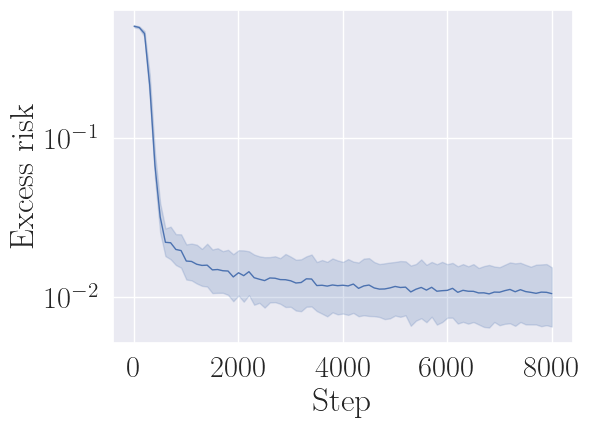

In [15]:
sns.lineplot(
    df,
    x="Step",
    y="Excess risk",
    linewidth=1.0,
)
plt.yscale('log')
plt.tight_layout()
plt.savefig("figures/excess_risk_single_head.pdf", bbox_inches="tight")
plt.show()

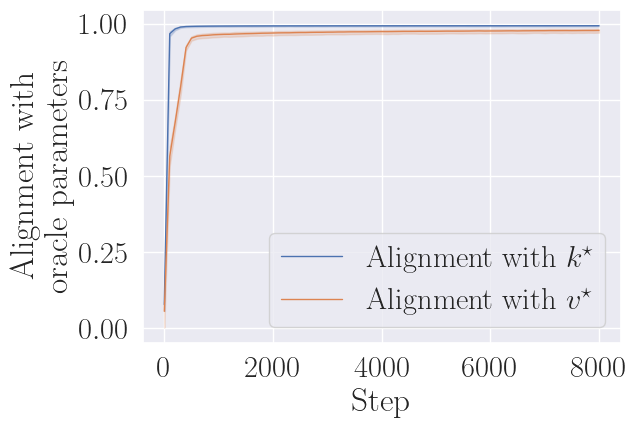

In [16]:
sns.lineplot(
    df,
    x="Step",
    y="Alignment with $k^\star$",
    linewidth=1.0,
    label=r"Alignment with $k^\star$",
)
sns.lineplot(
    df,
    x="Step",
    y="Alignment with $v^\star$",
    linewidth=1.0,
    label=r"Alignment with $v^\star$",
)
plt.tight_layout()
plt.ylabel("Alignment with \n oracle parameters")
plt.legend()
plt.savefig("figures/alignment_single_head.pdf", bbox_inches="tight")
plt.show()

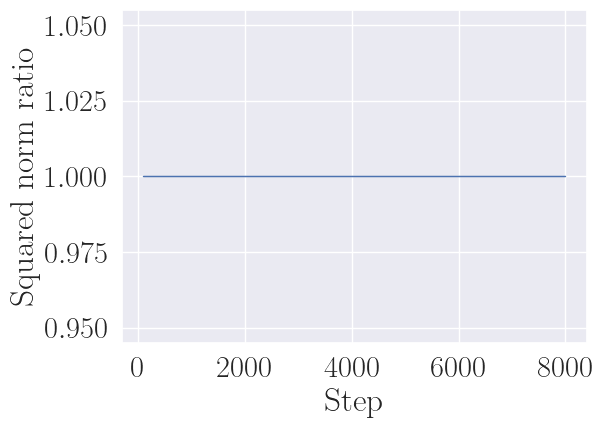

In [17]:
sns.lineplot(
    df,
    x="Step",
    y="Squared norm ratio",
    linewidth=1.0,
)
plt.tight_layout()
plt.show()